# Multivariate Regression - Optimized Solution

## Setup
---

In [1]:
# Use this to download and install packages in the notebook if needed
# !pip install -q numpy sympy matplotlib scikit-learn tqdm

In [2]:
# Needed libraries
import sys
import numpy as np
import sympy as sp
import matplotlib as mpl
import itertools as it      # needed for combinations and permutations
import sklearn as skl

# Needed submodules
from matplotlib import pyplot as plt    # needed for plotting
from sympy.polys.monomials import itermonomials     # needed for generating monomials
from tqdm import tqdm    # needed for progress bars
from sklearn.decomposition import PCA   # needed for PCA
from sklearn.manifold import TSNE       # needed for t-SNE
from sklearn.preprocessing import PolynomialFeatures  # needed for generating polynomial features
from sympy.polys.monomials import itermonomials
from sympy.polys.orderings import monomial_key
from typing import Iterable

# Check the versions
print("🐍 Python version:", sys.version)
print("📦 NumPy version:", np.__version__)
print("🔢 SymPy version:", sp.__version__)
print("📊 Matplotlib version:", mpl.__version__)
print("📈 scikit-learn version:", skl.__version__)

🐍 Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
📦 NumPy version: 2.3.3
🔢 SymPy version: 1.14.0
📊 Matplotlib version: 3.10.6
📈 scikit-learn version: 1.7.2


## Exploration

One important observation is that the matrix can be reorganized into a block-diagonal matrix, which is easy to see because:
$$e_i \cdot e_j = 0 \quad \forall i \ne j$$

So, our system decouples into $h$ smaller systems. We can use this information and many other tricks to devise a more efficient algorithm. 

$$
A \;=\;
\begin{array}{ccc}
  & 
  
    e_1 \quad\;e_2 \quad\; \cdots \quad\; e_n
  
  & \\[1ex]
%
  \left. \,
    \begin{matrix}
      e_1\\
      e_2\\
      \vdots\\
      e_h
    \end{matrix}
  \right.
  &
    \begin{bmatrix}
      A_1      & 0        & \cdots & 0      \\
      0        & A_2      & \cdots & 0      \\
      \vdots   & \vdots   & \ddots & \vdots \\
      0        & 0        & \cdots & A_h
    \end{bmatrix}
  &
  \left.
    \begin{matrix}
      \\ \\ \\ 
    \end{matrix}
  \right.
\end{array}
$$


Now, let's see that in action in a toy problem. First, we create a list of terms ordered by $\hat e_i$:

In [3]:
# Parameters
n = 2  # size of input
m = 2  # size of output
r = 2  # Maximum degree of the polynomial terms

# Create symbols
x = sp.symbols(f'x0:{n}')  # (x0, x1, x2)
e = sp.symbols(f'e0:{m}')  # (e0, e1)

# Generate all monomials up to degree r
key = monomial_key('grlex', x)     # or 'lex', 'grevlex'—pick one and keep it
terms = sorted(itermonomials(x, r), key=key)

print("Monomials:")
display(terms)

# Build all (monomial, unit-vector) pairs
pairs = [(ei, t) for ei in e for t in terms]

print("Pairs (unit-vector, monomial):")
display(pairs)

# If you want an expression like term * e_i:
exprs  = [t * ei for (ei, t) in pairs]   # your feature list in a stable, block order

print("Expressions (monomial * unit-vector):")
display(exprs)

# Quick check:
print(f"Total monomials:       {len(terms)}")
print(f"Total unit-vectors:    {len(e)}")
print(f"Total combinations:    {len(exprs)}")

Monomials:


[1, x1, x0, x1**2, x0*x1, x0**2]

Pairs (unit-vector, monomial):


[(e0, 1),
 (e0, x1),
 (e0, x0),
 (e0, x1**2),
 (e0, x0*x1),
 (e0, x0**2),
 (e1, 1),
 (e1, x1),
 (e1, x0),
 (e1, x1**2),
 (e1, x0*x1),
 (e1, x0**2)]

Expressions (monomial * unit-vector):


[e0,
 e0*x1,
 e0*x0,
 e0*x1**2,
 e0*x0*x1,
 e0*x0**2,
 e1,
 e1*x1,
 e1*x0,
 e1*x1**2,
 e1*x0*x1,
 e1*x0**2]

Total monomials:       6
Total unit-vectors:    2
Total combinations:    12


In [4]:
# Create the identity I_d
I = sp.eye(m)

# Create the substitution dictionary:
subs_map = { e[i]: I[:, i] for i in range(m) }

# Replace the unit vectors with their values
exprs_sub = [ex.subs(subs_map) for ex in exprs]

# Results
for ex in exprs_sub:
    display(ex)

Matrix([
[1],
[0]])

Matrix([
[x1],
[ 0]])

Matrix([
[x0],
[ 0]])

Matrix([
[x1**2],
[    0]])

Matrix([
[x0*x1],
[    0]])

...

Matrix([
[ 0],
[x1]])

Matrix([
[ 0],
[x0]])

Matrix([
[    0],
[x1**2]])

Matrix([
[    0],
[x0*x1]])

Matrix([
[    0],
[x0**2]])

In [5]:
# Define bounds
a, b = -1, 1
bounds = [(x_i, a, b) for x_i in x]

# Define the inner product function
inner_prod = lambda f, g, bounds: sp.integrate(f.dot(g), *bounds)

# Build Gram matrix
gram_matrix = sp.zeros(len(exprs_sub), len(exprs_sub))
for i in range(len(exprs_sub)):
    for j in range(len(exprs_sub)):
        gram_matrix[i, j] = inner_prod(exprs_sub[i], exprs_sub[j], bounds)

print("Gram matrix:")
display(gram_matrix)

Gram matrix:


Matrix([
[  4,   0,   0, 4/3,   0, 4/3,   0,   0,   0,   0,   0,   0],
[  0, 4/3,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
[  0,   0, 4/3,   0,   0,   0,   0,   0,   0,   0,   0,   0],
[4/3,   0,   0, 4/5,   0, 4/9,   0,   0,   0,   0,   0,   0],
[  0,   0,   0,   0, 4/9,   0,   0,   0,   0,   0,   0,   0],
[4/3,   0,   0, 4/9,   0, 4/5,   0,   0,   0,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   4,   0,   0, 4/3,   0, 4/3],
[  0,   0,   0,   0,   0,   0,   0, 4/3,   0,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   0, 4/3,   0,   0,   0],
[  0,   0,   0,   0,   0,   0, 4/3,   0,   0, 4/5,   0, 4/9],
[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 4/9,   0],
[  0,   0,   0,   0,   0,   0, 4/3,   0,   0, 4/9,   0, 4/5]])

Now, notice the structure of the matrix. We have a matrix:

$$
\begin{bmatrix}
A_{6 \times 6} & 0_{6 \times 6} \\
0_{6 \times 6} & A_{6 \times 6}
\end{bmatrix}_{12 \times 12}
$$

We can isolate the $A$ block and reuse it many times to solve the different subproblems. That can even be done in parallel!

In [6]:
# Isolate the blocks
A_1 = gram_matrix[0:6, 0:6]
A_2 = gram_matrix[6:13, 6:13]
Z_1 = gram_matrix[0:6, 6:13]
Z_2 = gram_matrix[6:13, 0:6]

# Display the blocks
print("Block A_1:")
display(A_1)
print("Block A_2:")
display(A_2)
print("Block Z_1 (off-diagonal):")
display(Z_1)
print("Block Z_2 (off-diagonal):")
display(Z_2)

# Sanity check: are the blocks equal?
print("Are A_1 and A_2 equal?", "yes" if A_1.equals(A_2) else "no")
print("Are Z_1 and Z_2 zero matrices?", "yes" if Z_1.is_zero_matrix and Z_2.is_zero_matrix else "no")

Block A_1:


Matrix([
[  4,   0,   0, 4/3,   0, 4/3],
[  0, 4/3,   0,   0,   0,   0],
[  0,   0, 4/3,   0,   0,   0],
[4/3,   0,   0, 4/5,   0, 4/9],
[  0,   0,   0,   0, 4/9,   0],
[4/3,   0,   0, 4/9,   0, 4/5]])

Block A_2:


Matrix([
[  4,   0,   0, 4/3,   0, 4/3],
[  0, 4/3,   0,   0,   0,   0],
[  0,   0, 4/3,   0,   0,   0],
[4/3,   0,   0, 4/5,   0, 4/9],
[  0,   0,   0,   0, 4/9,   0],
[4/3,   0,   0, 4/9,   0, 4/5]])

Block Z_1 (off-diagonal):


Matrix([
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0]])

Block Z_2 (off-diagonal):


Matrix([
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0]])

Are A_1 and A_2 equal? yes
Are Z_1 and Z_2 zero matrices? yes


The same thing happens in the discrete case:

In [7]:
# Define the discrete product function
discrete_prod = lambda f, g, points: sum([f.dot(g).subs({x_i: p_i for x_i, p_i in zip(x, p)}) for p in points])

# Example points for discrete product
points = [(0, 0), (0.5, 0.5), (1, 1), (-0.5, -0.5), (-1, -1)]

# Build Gram matrix
disc_gram_matrix = sp.zeros(len(exprs_sub), len(exprs_sub))
for i in range(len(exprs_sub)):
    for j in range(len(exprs_sub)):
        disc_gram_matrix[i, j] = discrete_prod(exprs_sub[i], exprs_sub[j], points)

print("Gram matrix (Discrete Case):")
display(disc_gram_matrix)

Gram matrix (Discrete Case):


Matrix([
[  5,   0,   0,   2.5,   2.5,   2.5,   0,   0,   0,     0,     0,     0],
[  0, 2.5, 2.5,     0,     0,     0,   0,   0,   0,     0,     0,     0],
[  0, 2.5, 2.5,     0,     0,     0,   0,   0,   0,     0,     0,     0],
[2.5,   0,   0, 2.125, 2.125, 2.125,   0,   0,   0,     0,     0,     0],
[2.5,   0,   0, 2.125, 2.125, 2.125,   0,   0,   0,     0,     0,     0],
[2.5,   0,   0, 2.125, 2.125, 2.125,   0,   0,   0,     0,     0,     0],
[  0,   0,   0,     0,     0,     0,   5,   0,   0,   2.5,   2.5,   2.5],
[  0,   0,   0,     0,     0,     0,   0, 2.5, 2.5,     0,     0,     0],
[  0,   0,   0,     0,     0,     0,   0, 2.5, 2.5,     0,     0,     0],
[  0,   0,   0,     0,     0,     0, 2.5,   0,   0, 2.125, 2.125, 2.125],
[  0,   0,   0,     0,     0,     0, 2.5,   0,   0, 2.125, 2.125, 2.125],
[  0,   0,   0,     0,     0,     0, 2.5,   0,   0, 2.125, 2.125, 2.125]])

We can use scikit-learn's `PolynomialFeatures` to compute that block using fast numerical methods.

In [8]:
def gram_block_with_sklearn(points, degree, include_bias=True, interaction_only=False, weights=None):
    """
    Returns the Gram block G_block = V^T V, where V are all monomials
    up to 'degree' evaluated at 'points'.
    """
    # Ensure the points are in a NumPy array
    X = np.asarray(points, dtype=float)           # shape (P, n)
    
    # Using polynomial features from sklearn to generate the Vandermonde matrix
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=include_bias,                # include constant 1 term (matches itermonomials)
        interaction_only=interaction_only,        # set True to exclude powers like x0^2
        order="C",
        # for sklearn<1.2 use 'sparse=False'; for >=1.2 use 'sparse_output=False'
    )

    # Fit to data and transform
    V = poly.fit_transform(X)                     # (P, T)

    # If no weights (standard case), compute G_block = V^T V
    if weights is None:
        G_block = V.T @ V
    else:
        w = np.asarray(weights, dtype=float).reshape(-1, 1)  # (P,1)
        G_block = V.T @ (w * V)                   # V^T W V without forming diag(W)
    
    # NOTE: use the poly object to get feature names if needed
    return G_block, poly, V

def full_gram_from_block(G_block, m):
    """Materialize the full Gram (I_m ⊗ G_block). Avoid if m is large."""
    return np.kron(np.eye(m), G_block)

In [9]:
# Using our optimized function
opt_graham_block, poly, V = gram_block_with_sklearn(points, degree=r)
opt_graham_matrix = full_gram_from_block(opt_graham_block, m)

print("Optimized Gram block from scikit-learn:")
display(sp.Matrix(opt_graham_block))

print("Full Gram matrix from optimized block:")
display(sp.Matrix(opt_graham_matrix))

# Compare with previous results
difference = sum(abs(disc_gram_matrix - sp.Matrix(opt_graham_matrix)))
print("Difference between discrete Gram matrix and optimized Gram matrix:", difference)

Optimized Gram block from scikit-learn:


Matrix([
[5.0, 0.0, 0.0,   2.5,   2.5,   2.5],
[0.0, 2.5, 2.5,   0.0,   0.0,   0.0],
[0.0, 2.5, 2.5,   0.0,   0.0,   0.0],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125]])

Full Gram matrix from optimized block:


Matrix([
[5.0, 0.0, 0.0,   2.5,   2.5,   2.5, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[0.0, 2.5, 2.5,   0.0,   0.0,   0.0, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[0.0, 2.5, 2.5,   0.0,   0.0,   0.0, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[2.5, 0.0, 0.0, 2.125, 2.125, 2.125, 0.0, 0.0, 0.0,   0.0,   0.0,   0.0],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 5.0, 0.0, 0.0,   2.5,   2.5,   2.5],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 0.0, 2.5, 2.5,   0.0,   0.0,   0.0],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 0.0, 2.5, 2.5,   0.0,   0.0,   0.0],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 2.5, 0.0, 0.0, 2.125, 2.125, 2.125],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 2.5, 0.0, 0.0, 2.125, 2.125, 2.125],
[0.0, 0.0, 0.0,   0.0,   0.0,   0.0, 2.5, 0.0, 0.0, 2.125, 2.125, 2.125]])

Difference between discrete Gram matrix and optimized Gram matrix: 0


Using those methods and leveraging the power of ready-to-use and optimized libraries, we can replicate the symbolic workflow in a much cleaner and faster manner. 

## Efficient Solver

In [10]:
def build_design(X, degree, include_bias=True, interaction_only=False):
    """Return V (P ✕ T) and the fitted PolynomialFeatures object."""
    X = np.asarray(X, float)
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=include_bias,
        interaction_only=interaction_only,
        order="C",
    )
    V = poly.fit_transform(X)   # (P, T)
    return V, poly

def build_block_system(X, Y, degree, weights=None, include_bias=True, interaction_only=False):
    """
    Build the small normal-equations system:
      G_block (T ✕ T),  B (T ✕ m)
    such that G_block * A = B with A (T ✕ m) the coefficient matrix.
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    V, poly = build_design(X, degree, include_bias, interaction_only)

    if weights is None:
        G_block = V.T @ V                 # (T, T)
        B       = V.T @ Y                 # (T, m)
    else:
        w = np.asarray(weights, float).reshape(-1, 1)  # (P,1)
        G_block = V.T @ (w * V)
        B       = V.T @ (w * Y)
    return G_block, B, poly

def solve_blocks(G_block, B, ridge=0.0):
    """
    Solve G_block A = B for all outputs at once.
    If needed, add a tiny ridge for stability.
    """
    if ridge:
        G_block = G_block + ridge * np.eye(G_block.shape[0])
    A = np.linalg.solve(G_block, B)  # (T, m)
    return A

def predict_from_blocks(X_new, poly, A):
    """Evaluate predictions at new points using the learned A."""
    V_new = poly.transform(np.asarray(X_new, float))  # (P_new, T)
    return V_new @ A                                  # (P_new, m)

In [11]:
def regression(X, Y, degree: int, quiet: bool = False):
    """
    Fit a multivariate polynomial regression using the block Gram system.

    Parameters
    ----------
    X : array-like, shape (P, n)
        Input points.
    Y : array-like, shape (P, m)
        Targets; one column per output dimension.
    degree : int
        Maximum polynomial degree.
    quiet : bool
        If False, prints a brief warning when falling back to lstsq.

    Returns
    -------
    A : ndarray, shape (T, m)
        Coefficient matrix in the monomial basis (columns correspond to outputs).
        Ordering of rows matches `poly.powers_`.
    poly : PolynomialFeatures
        Fitted transformer; use `poly.transform(X_new)` to build features consistently.
        `poly.powers_` gives the exponent tuples for each row of `A`.
    predict : callable
        Function `predict(X_new) -> (P_new, m)` for fast evaluation.
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    assert X.ndim == 2 and Y.ndim == 2 and X.shape[0] == Y.shape[0], "Shape mismatch between X and Y"

    # Build block system
    G_block, B, poly = build_block_system(X, Y, degree, weights=None, include_bias=True, interaction_only=False)

    # Try direct solve; if ill-conditioned, fall back to least-squares on the design matrix
    cond = np.linalg.cond(G_block)
    if not np.isfinite(cond) or cond > 1e12:
        if not quiet:
            print("[regression] Warning: Gram block is ill-conditioned "
                  f"(cond≈{cond:.2e}); falling back to lstsq on design matrix.")
        V, _ = build_design(X, degree, include_bias=True, interaction_only=False)
        A, *_ = np.linalg.lstsq(V, Y, rcond=None)   # (T, m)
    else:
        A = solve_blocks(G_block, B)                # (T, m)

    # Predictor closure
    def predict(X_new):
        return predict_from_blocks(X_new, poly, A)

    return A, poly, predict

## Handling a very large P

Handling a very large $P$ is challenging with our current implementation because the full design matrix may not fit in memory. In that scenario we accumulate the normal equations instead of materialising the original design matrix $V$ $(P \times T)$.

$$
G_{\text{block}}=\sum_b V_b^\top V_b,\qquad
B=\sum_b V_b^\top Y_b
$$


In [12]:
def _init_poly_from_n(n:int, degree:int, include_bias:bool, interaction_only:bool):
    """Create a fitted PolynomialFeatures using only the feature count n."""
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=include_bias,
        interaction_only=interaction_only,
        order="C",
    )
    # Fit on a 1-row dummy just to populate powers_/n_output_features_
    poly.fit(np.zeros((1, n), float))
    return poly

def _accumulate_GB(G, B, Xb, Yb, poly, wb=None):
    """Accumulate into G (T✕T) and B (T✕m) from one batch."""
    Vb = poly.transform(np.asarray(Xb, float))  # (Pb, T)
    Yb = np.asarray(Yb, float)                  # (Pb, m)
    if wb is None:
        G += Vb.T @ Vb
        B += Vb.T @ Yb
    else:
        w = np.asarray(wb, float).reshape(-1, 1)  # (Pb, 1)
        G += Vb.T @ (w * Vb)
        B += Vb.T @ (w * Yb)

In [13]:
def regression_largeP(
    X: np.ndarray,
    Y: np.ndarray,
    degree: int,
    *,
    batch_size: int = 8192,
    weights: np.ndarray | None = None,
    include_bias: bool = True,
    interaction_only: bool = False,
    ridge: float = 0.0,
    quiet: bool = False,
):
    """
    Out-of-core regression for large P using batches from NumPy arrays.

    Returns
    -------
    A : (T, m) coefficient matrix
    poly : fitted PolynomialFeatures (defines monomial order via poly.powers_)
    predict : callable, predict(X_new) -> (P_new, m)
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    assert X.ndim == 2 and Y.ndim == 2 and X.shape[0] == Y.shape[0]
    P, n = X.shape
    m = Y.shape[1]
    if weights is not None:
        weights = np.asarray(weights, float)
        assert weights.shape[0] == P

    # Build transformer from n only (no need to see full X)
    poly = _init_poly_from_n(n, degree, include_bias, interaction_only)
    T = poly.n_output_features_

    G = np.zeros((T, T), dtype=float)
    B = np.zeros((T, m), dtype=float)

    # stream over rows
    for start in range(0, P, batch_size):
        stop = min(start + batch_size, P)
        Xb = X[start:stop]
        Yb = Y[start:stop]
        wb = None if weights is None else weights[start:stop]
        _accumulate_GB(G, B, Xb, Yb, poly, wb)

    # Solve G A = B (optionally with ridge)
    if ridge:
        G = G + ridge * np.eye(T)
    # Guard against ill-conditioning
    cond = np.linalg.cond(G)
    if not np.isfinite(cond) or cond > 1e12:
        if not quiet:
            print(f"[regression_largeP] Warning: Gram block ill-conditioned (cond≈{cond:.2e}). "
                  f"Adding ridge {max(ridge,1e-8):.1e}.")
        G = G + max(ridge, 1e-8) * np.eye(T)
    A = np.linalg.solve(G, B)

    def predict(X_new):
        return predict_from_blocks(X_new, poly, A)

    return A, poly, predict

# ---------- iterator-based large-P ----------
Batch =  tuple[np.ndarray, np.ndarray] | tuple[np.ndarray, np.ndarray, np.ndarray]

def regression_largeP_iter(
    batch_iter: Iterable[Batch],
    degree: int,
    *,
    n: int | None = None,
    include_bias: bool = True,
    interaction_only: bool = False,
    ridge: float = 0.0,
    quiet: bool = False,
):
    """
    Out-of-core regression where `batch_iter` yields batches:
        (Xb, Yb)  or  (Xb, Yb, wb)
    Shapes: Xb (Pb, n), Yb (Pb, m), wb (Pb,)

    Returns (A, poly, predict).
    """
    it = iter(batch_iter)
    try:
        first = next(it)
    except StopIteration:
        raise ValueError("Empty iterator")

    if len(first) == 2:
        Xb0, Yb0 = first
        wb0 = None
    elif len(first) == 3:
        Xb0, Yb0, wb0 = first
    else:
        raise ValueError("Batches must be (Xb, Yb) or (Xb, Yb, wb)")

    Xb0 = np.asarray(Xb0, float)
    Yb0 = np.asarray(Yb0, float)
    if n is None:
        n = Xb0.shape[1]
    m = Yb0.shape[1]

    poly = _init_poly_from_n(n, degree, include_bias, interaction_only)
    T = poly.n_output_features_
    G = np.zeros((T, T), dtype=float)
    B = np.zeros((T, m), dtype=float)

    # process first + rest
    _accumulate_GB(G, B, Xb0, Yb0, poly, wb0)
    for batch in it:
        if len(batch) == 2:
            Xb, Yb = batch
            wb = None
        else:
            Xb, Yb, wb = batch
        _accumulate_GB(G, B, Xb, Yb, poly, wb)

    if ridge:
        G = G + ridge * np.eye(T)
    cond = np.linalg.cond(G)
    if not np.isfinite(cond) or cond > 1e12:
        if not quiet:
            print(f"[regression_largeP_iter] Warning: Gram block ill-conditioned (cond≈{cond:.2e}). "
                  f"Adding ridge {max(ridge,1e-8):.1e}.")
        G = G + max(ridge, 1e-8) * np.eye(T)
    A = np.linalg.solve(G, B)

    def predict(X_new):
        return predict_from_blocks(X_new, poly, A)

    return A, poly, predict


## Execution

With the building blocks in place, we can revisit the synthetic manifold dataset from the first notebook and verify that the optimized routines behave the same while being simpler to orchestrate.

In [14]:

def make_helix_dataset(num_points: int, n: int, m: int, *, seed: int | None = None, noise: float = 0.0):
    """
    Generate a structured dataset for R^n -> R^m regressions.

    The samples trace a multi-frequency helix so that input and output
    coordinates share correlated, non-linear structure.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, 4 * np.pi, num_points)
    total = n + m
    Z = np.zeros((num_points, total), dtype=float)

    for i in range(total // 2):
        Z[:, 2 * i] = np.sin((i + 1) * t)
        Z[:, 2 * i + 1] = np.cos((i + 1) * t)

    if total % 2:
        Z[:, -1] = t / t.max()

    if noise > 0:
        Z += rng.normal(scale=noise, size=Z.shape)

    X = Z[:, :n]
    Y = Z[:, n:]
    return X, Y


In [15]:

def preview_dataset(X: np.ndarray, Y: np.ndarray, *, reduction: str = 'pca'):
    X = np.asarray(X)
    Y = np.asarray(Y)
    Z = np.hstack([X, Y])
    total_dim = Z.shape[1]

    if total_dim <= 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d') if total_dim == 3 else None
        if total_dim == 3:
            ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c='C0', s=10)
            ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
            ax.set_title('3D view of the coupled manifold')
        else:
            plt.scatter(Z[:, 0], Z[:, 1], c='C0', s=10)
            plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
            plt.title('2D view of the coupled manifold')
        plt.show()
        return

    if reduction == 'tsne':
        Zr = TSNE(n_components=3, init='random', learning_rate='auto').fit_transform(Z)
    else:
        Zr = PCA(n_components=3).fit_transform(Z)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(Zr[:, 0], Zr[:, 1], Zr[:, 2], c='C1', s=10)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
    ax.set_title(f'{reduction.upper()} preview ({total_dim} → 3 dims)')
    plt.show()


X shape: (1500, 3)
Y shape: (1500, 2)


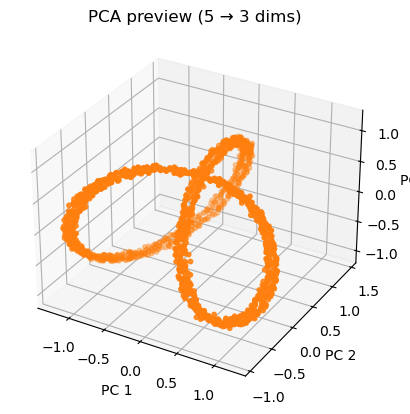

In [16]:

# Generate and preview the dataset
X, Y = make_helix_dataset(num_points=1500, n=3, m=2, seed=7, noise=0.02)
print('X shape:', X.shape)
print('Y shape:', Y.shape)
preview_dataset(X, Y)


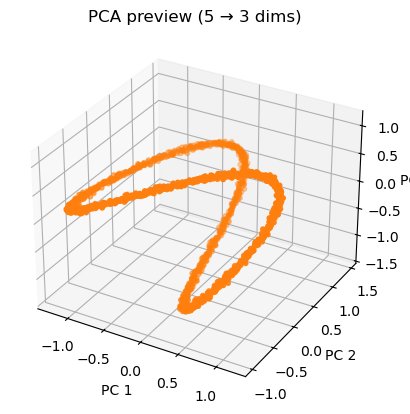

In [21]:
A, poly, predict = regression(X, Y, degree=1)
Y_pred = predict(X)

preview_dataset(X, Y_pred)

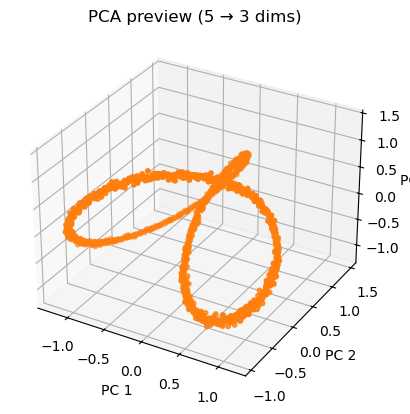

In [22]:
A, poly, predict = regression(X, Y, degree=3)
Y_pred = predict(X)

preview_dataset(X, Y_pred)

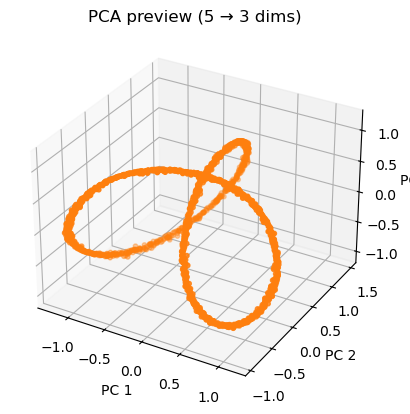

In [23]:
A, poly, predict = regression(X, Y, degree=5)
Y_pred = predict(X)

preview_dataset(X, Y_pred)

Next, we fit a sequence of polynomial regressors with our optimized solver to illustrate how the block-structured normal equations are reused across output dimensions.

Degree: 100%|██████████| 5/5 [00:00<00:00, 281.12it/s]


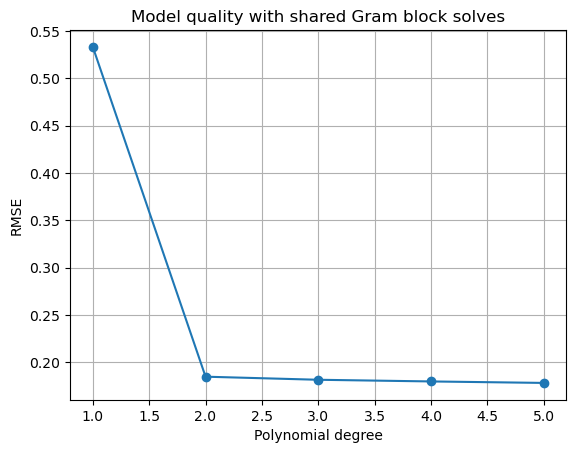

In [17]:

degrees = range(1, 6)
errors = []
solutions = []
for d in tqdm(degrees, desc='Degree'):
    A, poly, predict = regression(X, Y, degree=d, quiet=True)
    Y_pred = predict(X)
    rmse = np.sqrt(np.mean((Y_pred - Y) ** 2))
    errors.append(rmse)
    solutions.append((d, A, poly))

plt.figure()
plt.plot(list(degrees), errors, marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('RMSE')
plt.title('Model quality with shared Gram block solves')
plt.grid(True)
plt.show()


The streaming variant lets us scale to datasets that do not fit in memory by accumulating batches while keeping the exact same algebra.

In [18]:

# Large-P experiment: compare in-core and streaming solvers
X_big, Y_big = make_helix_dataset(num_points=40000, n=3, m=2, seed=123, noise=0.01)
A_full, poly_full, predict_full = regression(X_big, Y_big, degree=3, quiet=True)
Y_full = predict_full(X_big)
rmse_full = np.sqrt(np.mean((Y_full - Y_big) ** 2))

A_stream, poly_stream, predict_stream = regression_largeP(
    X_big, Y_big, degree=3, batch_size=4096, ridge=1e-10, quiet=True
)
Y_stream = predict_stream(X_big)
rmse_stream = np.sqrt(np.mean((Y_stream - Y_big) ** 2))

coef_diff = np.linalg.norm(A_full - A_stream, ord='fro')
print(f'RMSE (full solve):    {rmse_full:.6f}')
print(f'RMSE (streaming):    {rmse_stream:.6f}')
print(f'Coefficient Δ (Fro): {coef_diff:.3e}')


RMSE (full solve):    0.180324
RMSE (streaming):    0.180324
Coefficient Δ (Fro): 2.184e-11


Both routines converge to the same coefficients, but the streaming approach avoids materializing the full design matrix, delivering better memory usage at the cost of some additional processing time—an acceptable trade-off for large datasets.